In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, BatchNormalization, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [ ]:
TRAIN = "train/"
TEST = "test/"

DATASET_PATH = "/content/drive/MyDrive/AI_assignment/UCI_HAR_Dataset/"

In [ ]:
# Load "X"
def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []  # 한 센서축 데이터 전체 저장

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ')              # 공백 2개를 1개로
                row_clean = row_clean.strip()                   # 양쪽 공백 제거
                serie = row_clean.split(' ')                    # 공백 기준 split
                serie_array = np.array(serie, dtype=np.float32) # float32 numpy 배열로 변환
                series_list.append(serie_array)                 # 시퀀스 추가

        # 하나의 센서축 데이터 추가 (feature)
        X_signals.append(series_list)

    # shape: (특성 수, 샘플 수, 타임스텝 수)
    X_signals = np.array(X_signals)
    # shape 변환 → (샘플 수, 타임스텝 수, 특성 수)
    return np.transpose(X_signals, (1, 2, 0))


X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial_Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial_Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("첫 번째 샘플 데이터:\n", X_train[0])

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
첫 번째 샘플 데이터:
 [[ 1.808515e-04  1.076681e-02  5.556068e-02 ...  1.012817e+00
  -1.232167e-01  1.029341e-01]
 [ 1.013856e-02  6.579480e-03  5.512483e-02 ...  1.022833e+00
  -1.268756e-01  1.056872e-01]
 [ 9.275574e-03  8.928878e-03  4.840473e-02 ...  1.022028e+00
  -1.240037e-01  1.021025e-01]
 ...
 [-1.147484e-03  1.714439e-04  2.647864e-03 ...  1.018445e+00
  -1.240696e-01  1.003852e-01]
 [-2.222655e-04  1.574181e-03  2.381057e-03 ...  1.019372e+00
  -1.227451e-01  9.987355e-02]
 [ 1.575500e-03  3.070189e-03 -2.269757e-03 ...  1.021171e+00
  -1.213260e-01  9.498741e-02]]


In [ ]:
# Load "y"

def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    # 라벨을 0부터 시작하도록 -1 (원래 라벨이 1부터 시작)
    return np.array(labels, dtype=np.int32) - 1


y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print(y_train[:5])

y_train shape: (7352,)
y_test shape: (2947,)
[4 4 4 4 4]


# RNN 모델 설계
- Layer : rnn 층 3개 + Dense 층 2개

In [ ]:
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = 6

K.clear_session()

custom_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005, clipvalue=1.0)

model = Sequential([
            Input(shape=input_shape),

            # 첫번째 rnn층
            SimpleRNN(128, return_sequences=True, dropout=0.2),
            BatchNormalization(),

            # 두번째 rnn층
            SimpleRNN(128, kernel_regularizer=regularizers.l2(0.001), return_sequences=True, dropout=0.2),
            BatchNormalization(),

            # 세번째 rnn층
            SimpleRNN(64, dropout=0.2),
            BatchNormalization(),

            # dense층 2개
            Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
            BatchNormalization(),
            Dropout(0.5),
            Dense(num_classes, activation='softmax')
        ])

model.compile(
            optimizer=custom_optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['sparse_categorical_accuracy']
        )

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128, 128)       │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,798 (288.27 KB)

 Trainable params: 72,902 (284.77 KB)

 Non-trainable params: 896 (3.50 KB)

None


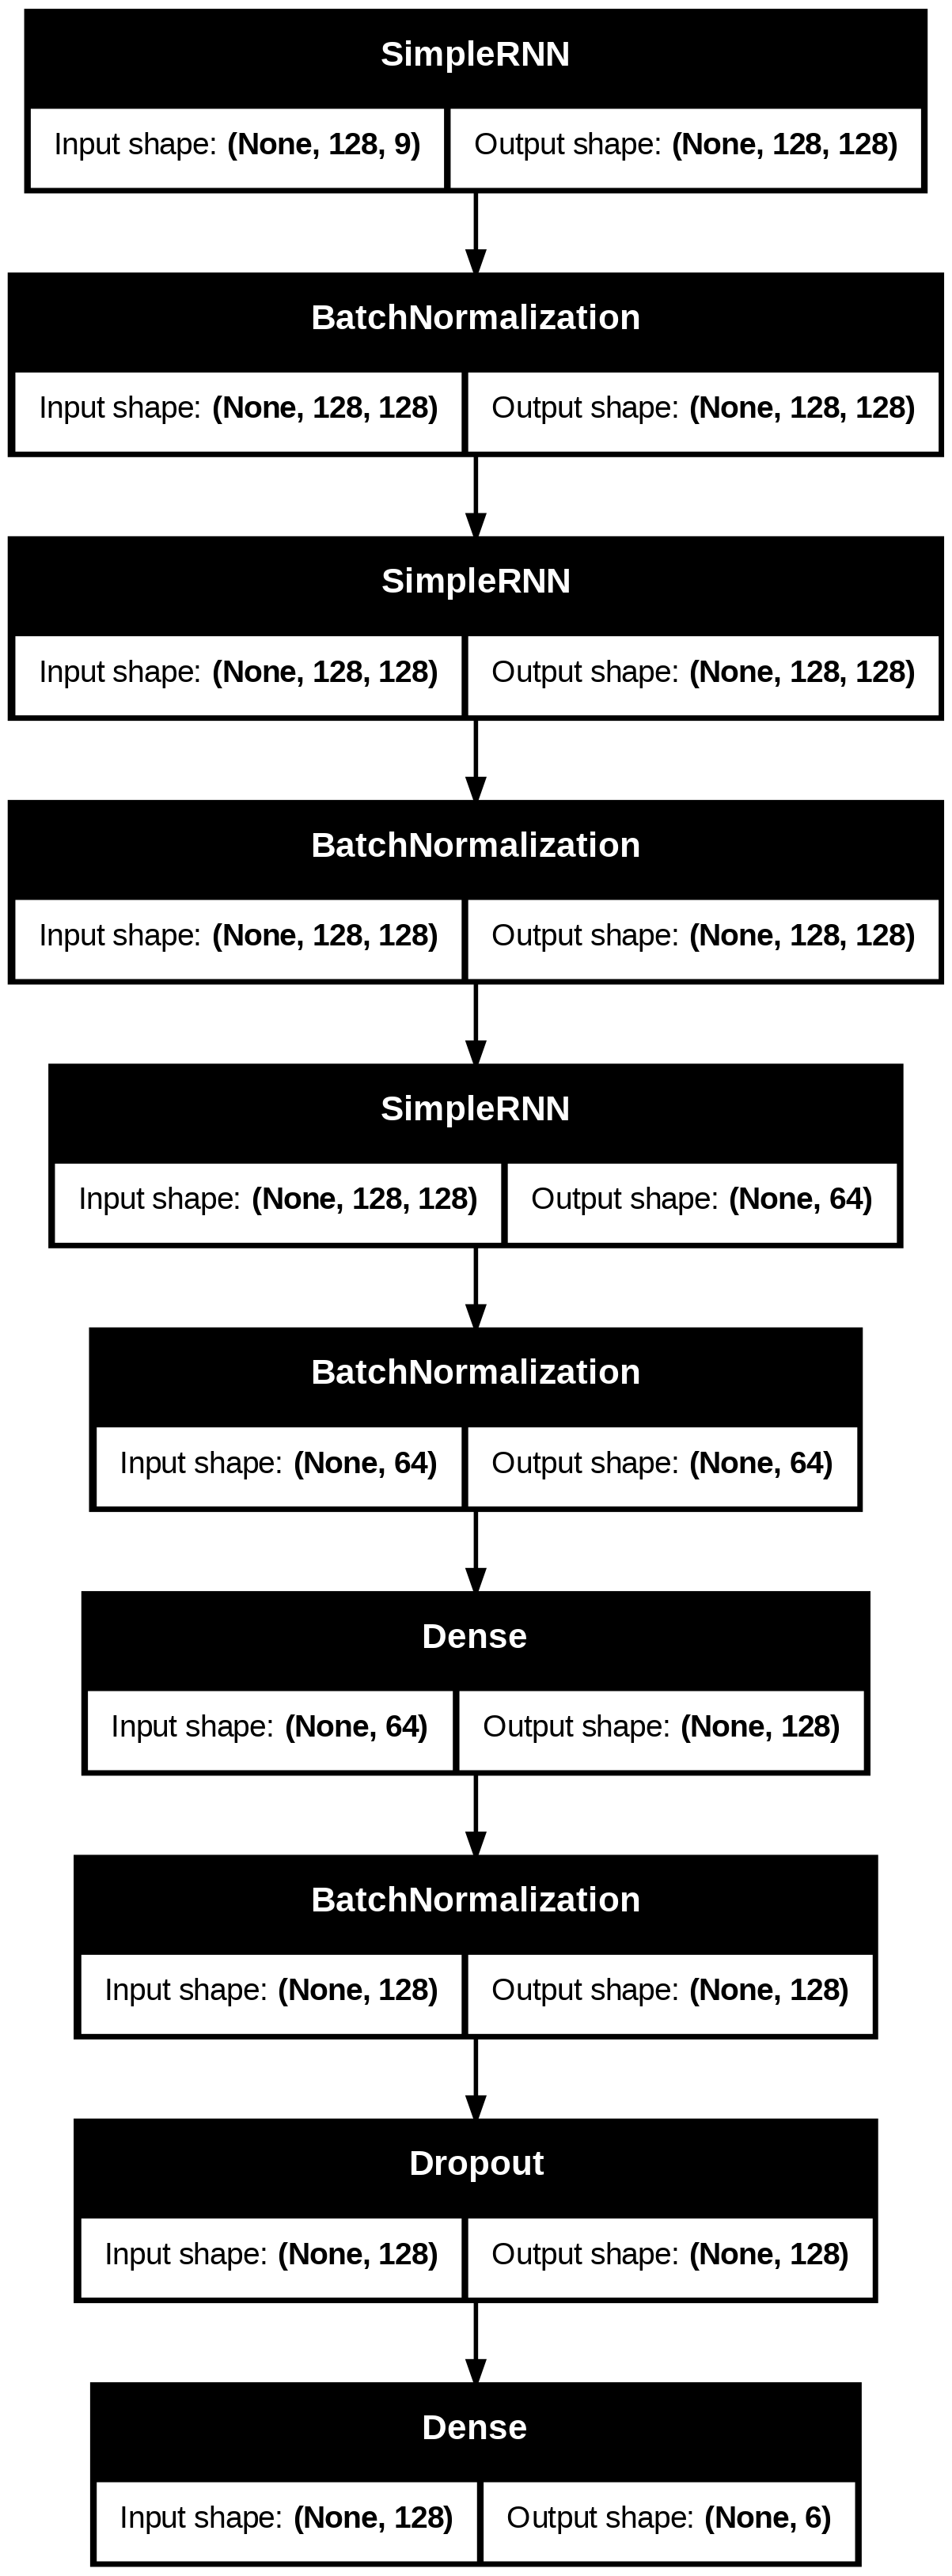

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)

# callbacks 설정

In [ ]:
callbacks = [
            ModelCheckpoint(
                "UCI_HAR_RNN_best.keras",
                save_best_only=True,
                monitor="val_sparse_categorical_accuracy",
                mode='max',
                verbose=1
            ),
            EarlyStopping(
                monitor="val_sparse_categorical_accuracy",
                patience=30,
                verbose=1,
                mode='max',
                restore_best_weights=True
            ),
            ReduceLROnPlateau(
                monitor='val_loss',    # val_loss 값을 지켜보다가
                factor=0.2,            # 학습에 발전이 없으면 LR에 0.2를 곱함 (기존의 1/5 수준으로 감소)
                patience=10,            # 5번 epochs 동안 성적이 안 오르면 실행
                min_lr=0.00001,        # 최소 LR 지정
                verbose=1              # LR이 바뀔 때 화면에 메시지 출력
            )
        ]

# 모델 학습

In [ ]:
history = model.fit(
            X_train, y_train,
            epochs=150,
            batch_size=64,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )

Epoch 1/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - loss: 2.2025 - sparse_categorical_accuracy: 0.3892
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.53773, saving model to UCI_HAR_RNN_best.keras

Epoch 1: finished saving model to UCI_HAR_RNN_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 200ms/step - loss: 1.9084 - sparse_categorical_accuracy: 0.4543 - val_loss: 1.6726 - val_sparse_categorical_accuracy: 0.5377 - learning_rate: 5.0000e-04
Epoch 2/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 1.4608 - sparse_categorical_accuracy: 0.5273
Epoch 2: val_sparse_categorical_accuracy did not improve from 0.53773
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 191ms/step - loss: 1.4028 - sparse_categorical_accuracy: 0.5479 - val_loss: 1.7214 - val_sparse_categorical_accuracy: 0.4521 - learning_rate: 5.0000e-04
Epoch 3/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 1.2947 - sparse_categorical_accuracy: 0.5708
Epoch 3: val_sparse_categorical_accuracy did not improve from 0.53773
92/92

# 모델 평가

In [ ]:
# best 기록 확인
model = tf.keras.models.load_model("UCI_HAR_RNN_best.keras")

train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 92.49%
Training loss: 0.3590
Test accuracy: 88.39%
Test loss: 0.5537


In [ ]:
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# 분류 리포트
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9242    0.9335    0.9288       496
           1     0.9083    0.8832    0.8956       471
           2     0.8632    0.9619    0.9099       420
           3     0.8288    0.7495    0.7872       491
           4     0.7965    0.8534    0.8240       532
           5     0.9881    0.9311    0.9588       537

    accuracy                         0.8839      2947
   macro avg     0.8849    0.8854    0.8840      2947
weighted avg     0.8857    0.8839    0.8837      2947



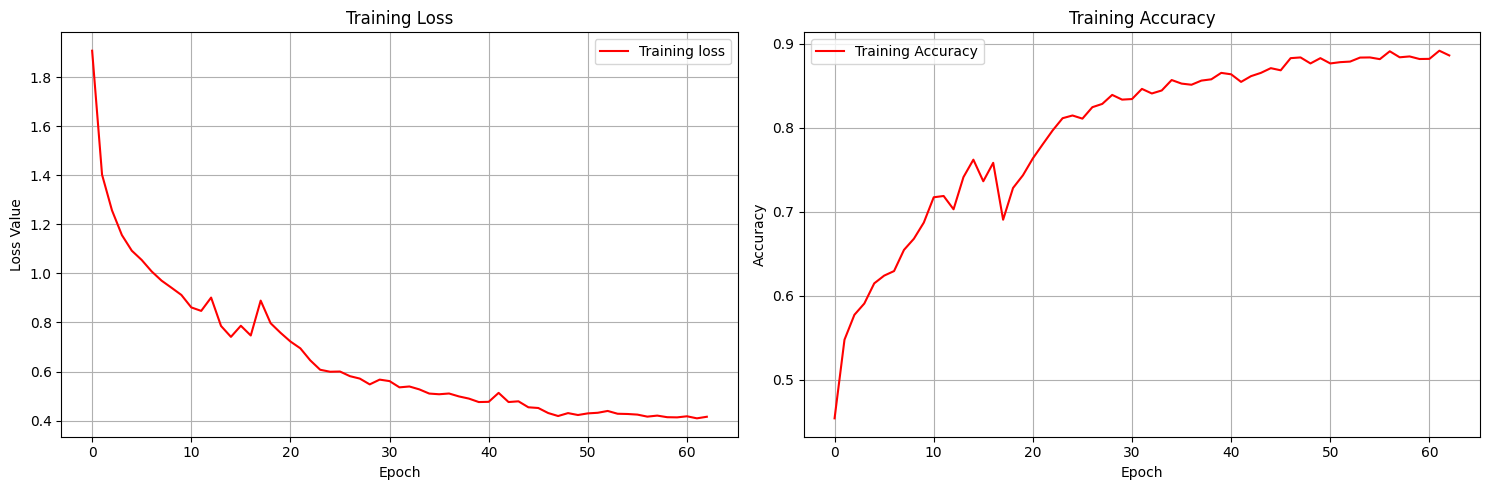

In [ ]:
# loss / accuracy 그래프
train_loss = history.history['loss']
train_accuracy = history.history['sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

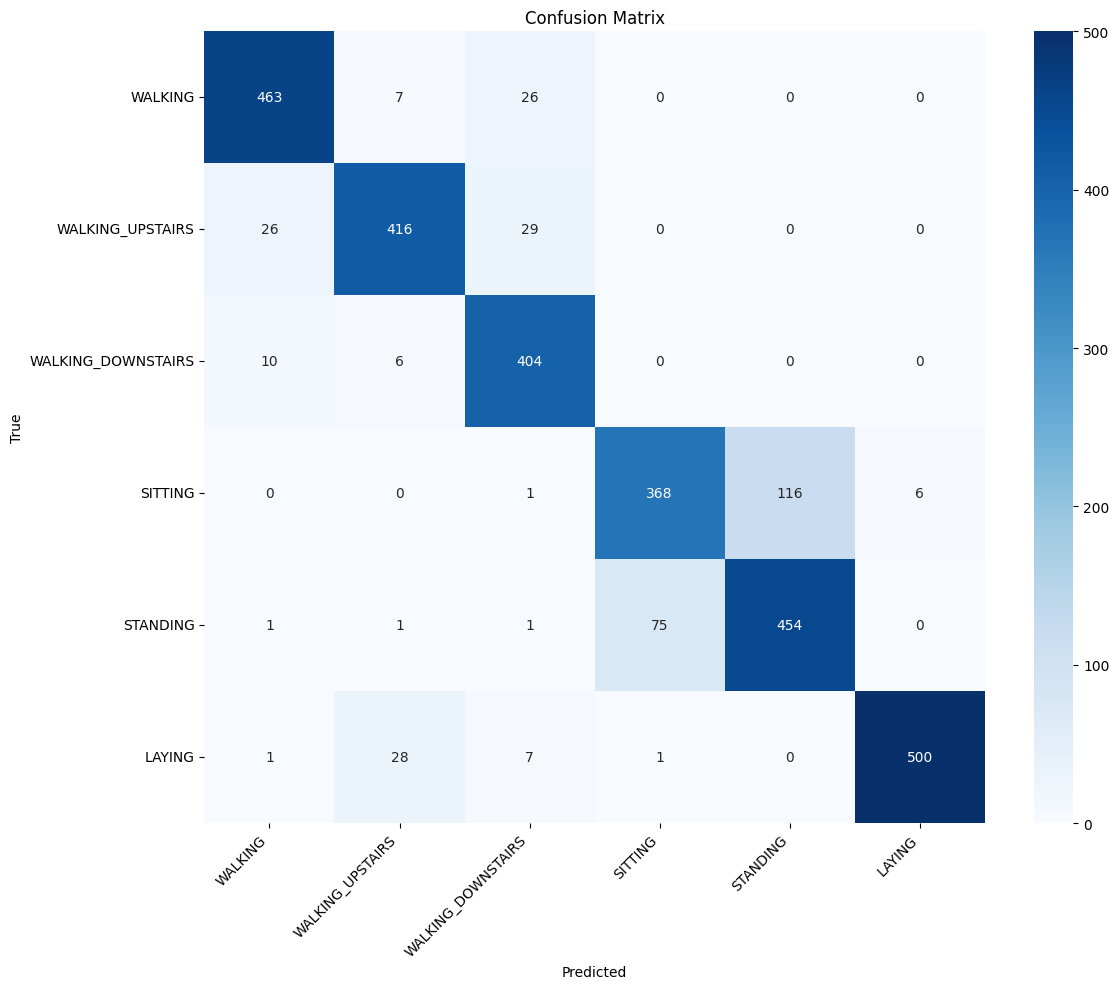

In [ ]:
# 히트맵
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

n_classes = len(np.unique(y_test))
if n_classes <= len(LABELS):
    plt.gca().set_xticklabels(LABELS[:n_classes], rotation=45, ha='right')
    plt.gca().set_yticklabels(LABELS[:n_classes], rotation=0)

plt.tight_layout()
plt.show()